![display relevant image here](path/url/to/image)
- Banner/header image

# Financial Loan Risk
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

Financial institutions process thousands of loan applications every year. Assessing whether an applicant should receive a loan is a critical task that directly affects profitability and financial stability. Traditionally, loan officers evaluate applications using an applicant's financial profile, employment history, creditworthiness, and other relevant factors.

As the volume of applications grows, manual decision-making becomes increasingly time-consuming and may lead to inconsistent evaluations. Machine learning offers an opportunity to support this process by identifying patterns in historical applicant data and predicting whether a loan should be approved.


## Business Problem

Loan approval decisions involve balancing two competing objectives:
- Approving creditworthy applicants to maximize revenue.
- Rejecting high-risk applicants to minimize potential financial losses.

Incorrect decisions can have significant consequences. Approving a high-risk applicant may increase the likelihood of loan default, while rejecting a qualified applicant represents a missed business opportunity and may negatively impact customer satisfaction.

The objective of this project is to build a predictive model that assists financial institutions in making consistent, data-driven loan approval decisions.

## Business Objectives

The project aims to:
- Predict whether a loan application should be approved.
- Identify the factors that most influence loan approval.
- Reduce the time required to evaluate loan applications.
- Support consistent and objective lending decisions.

## Stakeholders

The results of this project would be valuable to several stakeholders, including:
- Loan officers responsible for reviewing applications.
- Credit risk analysts who assess applicant risk.
- Bank management seeking to improve lending efficiency.
- Customers who benefit from faster and more consistent decisions.

## Success Criteria

From a business perspective, the project is successful if the model can support faster and more consistent loan approval decisions while minimizing risky approvals.

From a machine learning perspective, success will be evaluated using metrics such as:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Given the financial context, particular attention will be paid to balancing false approvals and false rejections.

## Data Understanding


In [51]:
# Imports
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings(action="ignore")

### Initial Data Inspection
The purpose of this section is to gain an overview of the dataset before performing any cleaning or analysis. We will examine the structure, dimensions, data types, and overall quality of the data to identify any issues that require attention.

In [52]:
# EDA Code Here - Create New Cells As Needed
# load the data 
df = pd.read_csv("financial_loan_data.csv")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 20000
Columns: 35


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [53]:
# Get dataset information 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [54]:
# summary statistics
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [55]:
# investigate the columns 
df.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='str')

### Dataset overview
Initial Observations (Markdown)

From the initial inspection, several points require further investigation:

- The dataset contains 20,000 observations and 35 variables.
- There are 28 numerical variables and 7 categorical variables.
- Two categorical variables (MaritalStatus and EducationLevel) contain missing values.
- One numerical (SavingsAccountBalance) variable also contains missing values.
- AnnualIncome is stored as a string instead of a numeric data type.
- Several variables appear to be closely related to the loan approval decision and may introduce target leakage if used during model training. e.g RiskScore

In [56]:
# Check for missing values 
missing = df.isna().sum().to_frame(name="Missing Values")
missing["percentage"] = round((missing["Missing Values"] / len(df)) * 100, 2)
missing = missing[missing["Missing Values"] > 0].sort_values("Missing Values", ascending=False)
missing

,Missing Values,percentage
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86


In [57]:
# Check for duplicated rows 
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [58]:
# Examine target variable 
print(df.LoanApproved.value_counts())
# df.LoanApproved.value_counts(normalize=True) * 100

LoanApproved
0    15220
1     4780
Name: count, dtype: int64


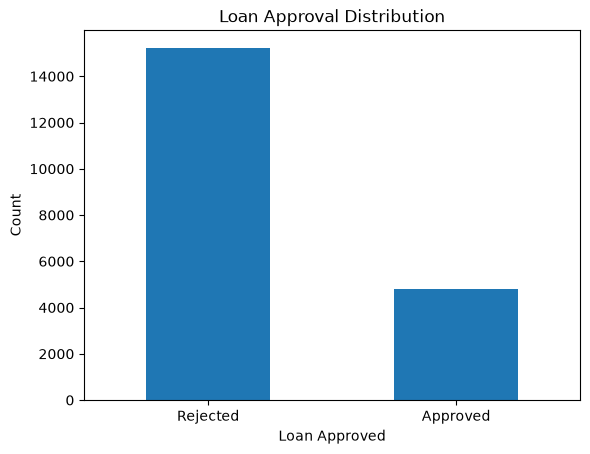

In [59]:
(
    df["LoanApproved"]
      .value_counts()
      .sort_index()
      .plot(kind="bar")
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")
plt.xticks([0, 1], ["Rejected", "Approved"], rotation=0)

plt.show()

In [60]:
# Investigate AnnualIncome column 
df.AnnualIncome.sample(5)

7773     $27,533.00
4006     $44,079.00
7438     $48,114.00
6176     $47,955.00
19510    $40,067.00
Name: AnnualIncome, dtype: str

### Potential Target Leakage
Some features may only be known after a loan has been approved. Including them in training would give the model information it wouldn't have at prediction time, resulting in unrealistically high performance.

Columns like Interest rate, Base interest rate, monthly loan payment, risk score, can only be known after the loan is approved

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



Missing saving account balance, it could mean:

- The customer has no savings account.
- The balance wasn't recorded.
- The data is missing at random.

In [61]:
# Inspect the column before filling 
df["SavingsAccountBalance"].describe()

count     19428.000000
mean       4949.148446
std        6628.404969
min          73.000000
25%        1542.000000
50%        2988.500000
75%        5869.250000
max      200089.000000
Name: SavingsAccountBalance, dtype: float64

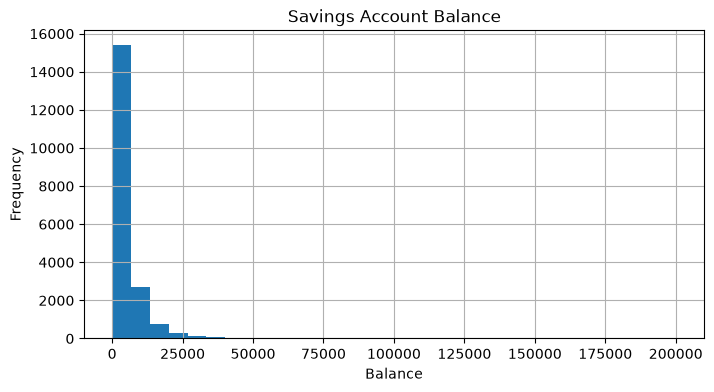

In [62]:
plt.figure(figsize=(8,4))

df["SavingsAccountBalance"].hist(bins=30)

plt.title("Savings Account Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

In [67]:
# Data Prep Code Here - Create New Cells As Needed
# convert annual income to float 

def cleaner(df):
    if df.AnnualIncome.dtype == "object":
        df.AnnualIncome = df.AnnualIncome.str.replace(r"[\$,]", "", regex=True).astype(float)

    # fill categorical values with unknown
    categorical_cols = ["MaritalStatus", "EducationLevel"]
    for col in categorical_cols:
        df[col] = df[col].fillna("Unknown")

    # fill the numerical with median 
    df['SavingsAccountBalance'] = df['SavingsAccountBalance'].fillna(df['SavingsAccountBalance'].median())    
    
    return df

In [70]:
# Run the dataframe through the cleaner function 
df = cleaner(df)

# verify missing values are gone 
df.isnull().sum().sort_values(ascending=False).head(5)

Age                 0
AnnualIncome        0
CreditScore         0
EmploymentStatus    0
EducationLevel      0
dtype: int64

In [72]:
# Seperate feature types
categorical_features = df.select_dtypes(include="object").columns.tolist()
numerical_features = df.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

Numerical Features
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']


<Axes: >

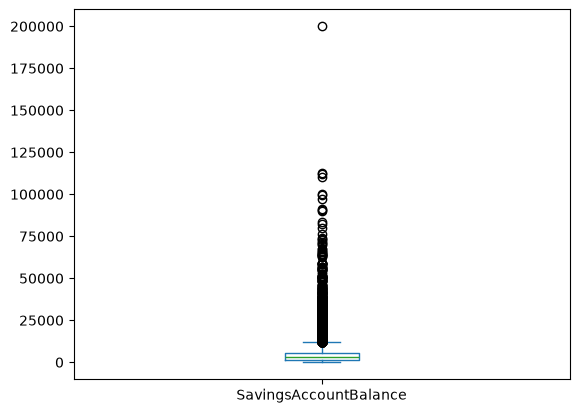

In [73]:
df["SavingsAccountBalance"].plot(kind="box")

## Feature Selection

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [ ]:
#  Modeling Code Here - Create New Cells as Needed
None

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements